COLAB E-iii — TensorFlow Functional API Regression

Cell 1 — Install & Imports

In [1]:
!pip install tensorflow scikit-learn matplotlib --quiet

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

tf.random.set_seed(42)
np.random.seed(42)

Cell 2 — Generate Synthetic 3-Variable Data

Same nonlinear regression function:
y=sin(x1​)+x22​+log(x32​+1)

In [2]:
N = 1000

x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-2, 2, N)
x3 = np.random.uniform(-2, 2, N)

X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
y = (np.sin(x1) + x2**2 + np.log(x3**2 + 1)).astype(np.float32).reshape(-1,1)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (1000, 3)
Output shape: (1000, 1)


Cell 3 — TensorFlow Functional API Model

Use tf.keras.Input() and connect layers manually:

In [3]:
inputs = tf.keras.Input(shape=(3,))

# Hidden layers
x = tf.keras.layers.Dense(64, activation="relu")(inputs)
x = tf.keras.layers.Dense(32, activation="tanh")(x)
x = tf.keras.layers.Dense(16, activation="relu")(x)

# Output layer
outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

Cell 4 — Compile Functional Model

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mse"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

Cell 5 — Train the Model

In [5]:
history = model.fit(X, y, epochs=500, batch_size=32, verbose=2)

Epoch 1/500
32/32 - 2s - 65ms/step - loss: 4.5816 - mse: 4.5816
Epoch 2/500
32/32 - 0s - 3ms/step - loss: 1.5863 - mse: 1.5863
Epoch 3/500
32/32 - 0s - 3ms/step - loss: 1.1534 - mse: 1.1534
Epoch 4/500
32/32 - 0s - 3ms/step - loss: 0.9102 - mse: 0.9102
Epoch 5/500
32/32 - 0s - 3ms/step - loss: 0.6788 - mse: 0.6788
Epoch 6/500
32/32 - 0s - 3ms/step - loss: 0.4930 - mse: 0.4930
Epoch 7/500
32/32 - 0s - 3ms/step - loss: 0.3782 - mse: 0.3782
Epoch 8/500
32/32 - 0s - 3ms/step - loss: 0.3075 - mse: 0.3075
Epoch 9/500
32/32 - 0s - 3ms/step - loss: 0.2572 - mse: 0.2572
Epoch 10/500
32/32 - 0s - 3ms/step - loss: 0.2191 - mse: 0.2191
Epoch 11/500
32/32 - 0s - 3ms/step - loss: 0.1893 - mse: 0.1893
Epoch 12/500
32/32 - 0s - 3ms/step - loss: 0.1644 - mse: 0.1644
Epoch 13/500
32/32 - 0s - 3ms/step - loss: 0.1446 - mse: 0.1446
Epoch 14/500
32/32 - 0s - 3ms/step - loss: 0.1275 - mse: 0.1275
Epoch 15/500
32/32 - 0s - 3ms/step - loss: 0.1132 - mse: 0.1132
Epoch 16/500
32/32 - 0s - 3ms/step - loss: 0.101

Cell 6 — Plot Training Loss

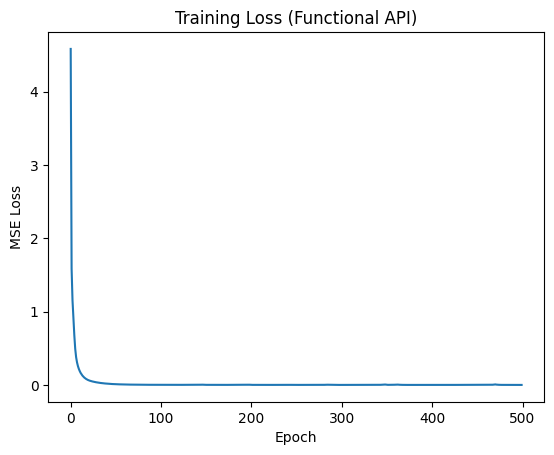

In [6]:
plt.plot(history.history["loss"], label="Training Loss")
plt.title("Training Loss (Functional API)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

plt.plot(history.history["loss"], label="Training Loss")
plt.title("Training Loss (Functional API)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


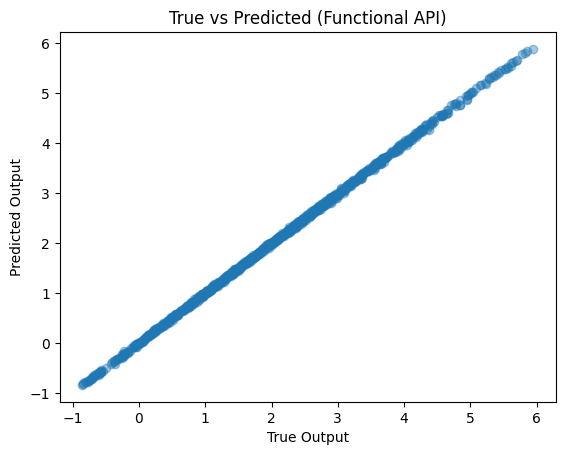

In [7]:
y_pred = model.predict(X)

plt.scatter(y, y_pred, alpha=0.4)
plt.xlabel("True Output")
plt.ylabel("Predicted Output")
plt.title("True vs Predicted (Functional API)")
plt.show()

Cell 8 — 4D Visualization via PCA

Reduce 3 inputs → 2D with PCA and plot regression.

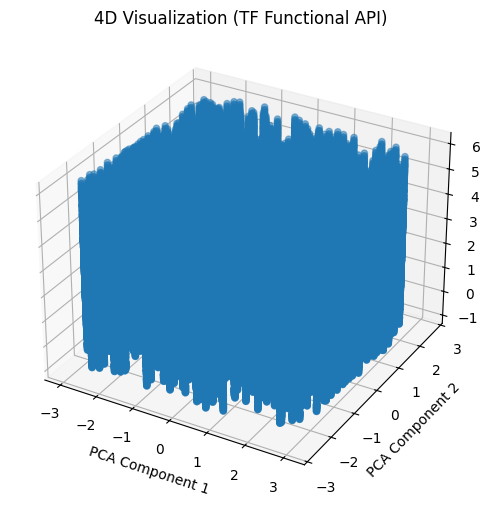

In [8]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_reduced[:,0], X_reduced[:,1], y, alpha=0.5)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("Regression Output")
plt.title("4D Visualization (TF Functional API)")
plt.show()